<a href="https://colab.research.google.com/github/sevval-345/SoftITo/blob/main/derin_ogrenme_basit.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🧠 Derin Öğrenme — Sıfırdan Başlayanlar İçin

Bu notebook'ta karmaşık formüller yok.  
Her kavramı **günlük hayattan örneklerle** ve **sade kodla** anlatacağız.

---

**Sıra:**
1. Nöron nedir?
2. Ağırlık ve bias ne işe yarar?
3. Aktivasyon fonksiyonu neden gerekli?
4. Kayıp fonksiyonu — model ne kadar yanılıyor?
5. Model nasıl öğrenir? (Gradient Descent)
6. PyTorch ile ilk sinir ağı
7. Eğitim döngüsü

## 📦 Gerekli Kütüphaneler

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim

print("Hazır! ✅")

Hazır! ✅


---
## 1. Nöron Nedir?

İnsan beyninde milyarlarca **nöron** (sinir hücresi) vardır.  
Birbirlerine sinyal gönderirler — bu sinyaller toplandığında düşünce ve karar oluşur.

Yapay sinir ağlarındaki nöron da aynı mantıkla çalışır:

```
  Girdiler       Nöron       Çıktı
  ────────       ──────      ──────
  sıcaklık ──→ ┐
  nem      ──→ ├──→ [topla + karar ver] ──→ "yağmur yağar mı?"
  basınç   ──→ ┘
```

**Nöron şunu yapar:**
1. Girdileri alır
2. Hepsini toplar
3. Bir karar verir (0 veya 1, ya da bir sayı)

In [2]:
# En basit nöron — sadece topla

def noron(girdiler):
    """Girdileri toplayıp bir sayı döndürür."""
    return sum(girdiler)

# Hava durumu tahmini için 3 girdi
sicaklik = 30   # derece
nem      = 80   # yüzde
basinc   = 10   # hPa

sonuc = noron([sicaklik, nem, basinc])
print(f"Nöron çıktısı: {sonuc}")
print("Ama bu pek kullanışlı değil... Neden? Hepsini eşit sayıyor!")
print("Çözüm → Ağırlıklar! 👇")

Nöron çıktısı: 120
Ama bu pek kullanışlı değil... Neden? Hepsini eşit sayıyor!
Çözüm → Ağırlıklar! 👇


---
## 2. Ağırlık ve Bias

**Ağırlık (weight):** Her girdinin ne kadar önemli olduğunu belirler.

Günlük hayat örneği:  
Bir restoranı değerlendirirken **yemek kalitesi** mi, **fiyat** mı, **atmosfer** mi daha önemli?  
Herkese göre ağırlık farklıdır!

```
yemek    × 0.6  ──→ ┐
fiyat    × 0.3  ──→ ├──→ toplam ──→ puan
atmosfer × 0.1  ──→ ┘
```

**Bias:** Nöronun "eğilimi". Tüm girdiler sıfır olsa bile nöronun bir çıktı üretmesini sağlar.


In [3]:
def agirlikli_noron(girdiler, agirliklar, bias):
    """
    Her girdiyi ağırlığıyla çarp, topla, bias ekle.
    Formül: z = w1*x1 + w2*x2 + ... + bias
    """
    z = sum(g * a for g, a in zip(girdiler, agirliklar)) + bias
    return z

# Restoran örneği (10 üzerinden puanlar)
girdiler   = [8, 6, 9]       # yemek, fiyat, atmosfer puanları
agirliklar = [0.6, 0.3, 0.1] # önem katsayıları (toplamı 1)
bias       = 0.5             # restoran zaten iyi bir yerdeyse ekstra puan

puan = agirlikli_noron(girdiler, agirliklar, bias)
print(f"Ağırlıklı toplam : {puan:.2f}")
print()
print("Detay:")
print(f"  Yemek    : 8  × 0.6 = {8*0.6}")
print(f"  Fiyat    : 6  × 0.3 = {6*0.3}")
print(f"  Atmosfer : 9  × 0.1 = {9*0.1}")
print(f"  Bias     :         = {bias}")
print(f"  Toplam   :         = {puan:.2f}")

Ağırlıklı toplam : 8.00

Detay:
  Yemek    : 8  × 0.6 = 4.8
  Fiyat    : 6  × 0.3 = 1.7999999999999998
  Atmosfer : 9  × 0.1 = 0.9
  Bias     :         = 0.5
  Toplam   :         = 8.00


---
## 3. Aktivasyon Fonksiyonu — "Karar Ver!"

Nöron topladıktan sonra bir **karar** vermesi gerekir.  
İşte aktivasyon fonksiyonu bunu sağlar.

**Neden gerekli?**  
Aktivasyon olmadan ne kadar katman eklersen ekle, model hep doğrusal (düz çizgi) kalır.  
Aktivasyon sayesinde model **karmaşık örüntüleri** öğrenebilir.

En popüler 3 aktivasyon:

| İsim | Ne Yapar | Ne Zaman |
|---|---|---|
| **ReLU** | Negatifse 0, pozitifse aynen geçir | Gizli katmanlar |
| **Sigmoid** | Her sayıyı 0–1 arasına sıkıştır | İkili sınıflandırma çıktısı |
| **Softmax** | Olasılık dağılımı üretir | Çok sınıflı çıktı |

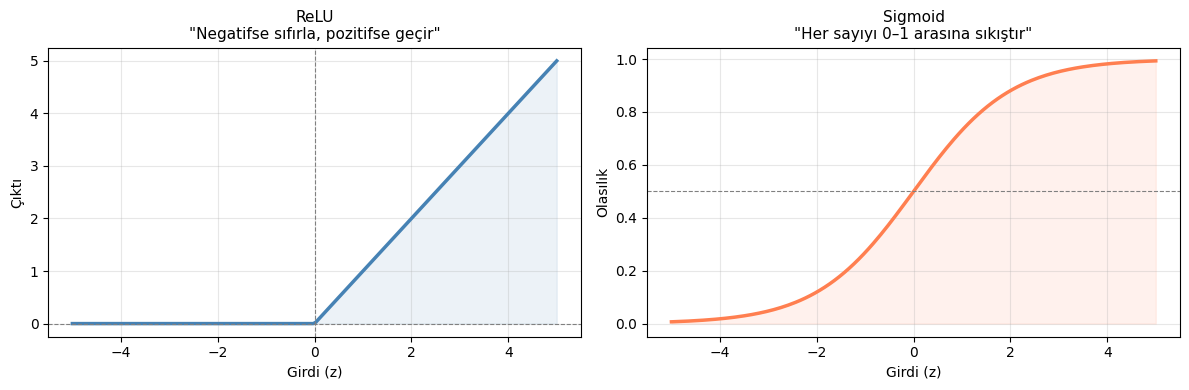

ReLU(-3) = 0   →  negatif, sıfırlandı
ReLU( 4) = 4   →  pozitif, geçti

Sigmoid(-5) = 0.007  →  0'a yakın
Sigmoid( 0) = 0.500  →  tam ortada
Sigmoid( 5) = 0.993  →  1'e yakın


In [4]:
x = np.linspace(-5, 5, 200)

relu    = np.maximum(0, x)
sigmoid = 1 / (1 + np.exp(-x))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(x, relu, color='steelblue', linewidth=2.5)
ax1.fill_between(x, relu, alpha=0.1, color='steelblue')
ax1.axhline(0, color='gray', linewidth=0.8, linestyle='--')
ax1.axvline(0, color='gray', linewidth=0.8, linestyle='--')
ax1.set_title('ReLU\n"Negatifse sıfırla, pozitifse geçir"', fontsize=11)
ax1.set_xlabel('Girdi (z)')
ax1.set_ylabel('Çıktı')
ax1.grid(True, alpha=0.3)

ax2.plot(x, sigmoid, color='coral', linewidth=2.5)
ax2.fill_between(x, sigmoid, alpha=0.1, color='coral')
ax2.axhline(0.5, color='gray', linewidth=0.8, linestyle='--')
ax2.set_title('Sigmoid\n"Her sayıyı 0–1 arasına sıkıştır"', fontsize=11)
ax2.set_xlabel('Girdi (z)')
ax2.set_ylabel('Olasılık')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Pratik örnek
print("ReLU(-3) =", max(0, -3), "  →  negatif, sıfırlandı")
print("ReLU( 4) =", max(0,  4), "  →  pozitif, geçti")
print()
print(f"Sigmoid(-5) = {1/(1+np.exp(5)):.3f}  →  0'a yakın")
print(f"Sigmoid( 0) = {1/(1+np.exp(0)):.3f}  →  tam ortada")
print(f"Sigmoid( 5) = {1/(1+np.exp(-5)):.3f}  →  1'e yakın")

---
## 4. Kayıp Fonksiyonu — "Ne Kadar Yanıldık?"

Model bir tahmin yapar. Ama bu tahmin ne kadar doğru?  
**Kayıp fonksiyonu** bunu ölçer.

Düşün: Okul sınavında 100 sorudan 30'unu yanlış yaptın.  
"Hata" = 30, "kayıp" = 30/100 = 0.30

**Amaç:** Eğitim sırasında bu kaybı mümkün olduğunca **küçültmek**.

En yaygın iki kayıp:
- **MSE (Ortalama Kare Hata):** Regresyon problemleri için  
  `kayıp = ortalama( (gerçek - tahmin)² )`
- **CrossEntropy:** Sınıflandırma problemleri için

In [5]:
# MSE ile kayıp hesabı — çok sade örnek

gercek   = np.array([3.0, 5.0, 7.0, 2.0, 9.0])
tahmin_1 = np.array([2.8, 5.1, 6.8, 2.3, 8.9])  # iyi tahmin
tahmin_2 = np.array([1.0, 8.0, 4.0, 6.0, 5.0])  # kötü tahmin

def mse(gercek, tahmin):
    hatalar = gercek - tahmin          # fark
    kareler = hatalar ** 2             # karesi (negatif olmaz)
    return kareler.mean()              # ortalaması

kayip_1 = mse(gercek, tahmin_1)
kayip_2 = mse(gercek, tahmin_2)

print("Gerçek değerler:", gercek)
print()
print(f"İyi  tahmin: {tahmin_1}")
print(f"→ Kayıp: {kayip_1:.4f}  ✅ Düşük kayıp = iyi model")
print()
print(f"Kötü tahmin: {tahmin_2}")
print(f"→ Kayıp: {kayip_2:.4f}  ❌ Yüksek kayıp = kötü model")

Gerçek değerler: [3. 5. 7. 2. 9.]

İyi  tahmin: [2.8 5.1 6.8 2.3 8.9]
→ Kayıp: 0.0380  ✅ Düşük kayıp = iyi model

Kötü tahmin: [1. 8. 4. 6. 5.]
→ Kayıp: 10.8000  ❌ Yüksek kayıp = kötü model


---
## 5. Model Nasıl Öğrenir? — Gradient Descent

**Benzetme:** Gözlerin kapalı, dağın tepesine çıkmaya çalışıyorsun.  
Her adımda ayağınla yokuşun eğimini hissediyorsun ve aşağı doğru adım atıyorsun.

Model de aynı şekilde öğrenir:
1. Tahmini yap
2. Kaybı hesapla
3. "Hangi yöne gitsem kayıp azalır?" diye bak (gradyan)
4. Ağırlıkları o yönde küçük bir adım güncelle
5. Tekrar et → kayıp giderek azalır

```
Kayıp
  │  \            Gradyan = eğim
  │   \           Adım = öğrenme hızı × eğim
  │    \
  │     \_____
  └──────────────→ Ağırlık
         ↑
      minimum
```

Başlangıç: w=-2.00, kayıp=25.00

Adım  1: w=-1.0000, kayıp=16.000000
Adım  5: w=1.3616, kayıp=2.684355
Adım 10: w=2.4631, kayıp=0.288230
Adım 20: w=2.9424, kayıp=0.003323

Hedef w=3.0 idi → Bulduğumuz: w=2.9424 ✅


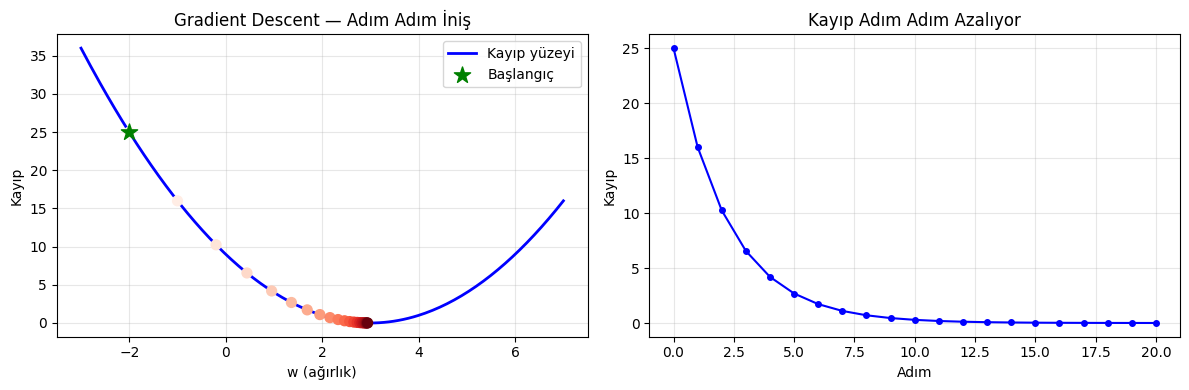

In [6]:
# Gradient descent'i 1 sayı üzerinde gösterelim
# Hedef: w=3 olan minimum kaybı bul
# Kayıp fonksiyonu: L(w) = (w - 3)²

w = -2.0           # başlangıç noktası
ogrenme_hizi = 0.1 # her adımda ne kadar ilerleyeceğiz

w_gecmis    = [w]
kayip_gecmis = [(w - 3)**2]

print(f"Başlangıç: w={w:.2f}, kayıp={kayip_gecmis[0]:.2f}")
print()

for adim in range(1, 21):
    gradyan = 2 * (w - 3)         # L'nin türevi: dL/dw = 2(w-3)
    w = w - ogrenme_hizi * gradyan # ağırlığı güncelle
    kayip = (w - 3)**2
    w_gecmis.append(w)
    kayip_gecmis.append(kayip)
    if adim in [1, 5, 10, 20]:
        print(f"Adım {adim:2d}: w={w:.4f}, kayıp={kayip:.6f}")

print(f"\nHedef w=3.0 idi → Bulduğumuz: w={w:.4f} ✅")

# Görselleştir
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

w_aralik = np.linspace(-3, 7, 200)
ax1.plot(w_aralik, (w_aralik-3)**2, 'b-', linewidth=2, label='Kayıp yüzeyi')
ax1.scatter(w_gecmis, [(wi-3)**2 for wi in w_gecmis],
            c=range(len(w_gecmis)), cmap='Reds', s=50, zorder=5)
ax1.scatter(w_gecmis[0], (w_gecmis[0]-3)**2, color='green', s=150, marker='*',
            zorder=6, label='Başlangıç')
ax1.set_title('Gradient Descent — Adım Adım İniş', fontsize=12)
ax1.set_xlabel('w (ağırlık)')
ax1.set_ylabel('Kayıp')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(kayip_gecmis, 'b-o', markersize=4)
ax2.set_title('Kayıp Adım Adım Azalıyor', fontsize=12)
ax2.set_xlabel('Adım')
ax2.set_ylabel('Kayıp')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## 6. PyTorch ile İlk Sinir Ağı

Artık tüm parçaları birleştirelim.

**Problem:** Bir kişi kredi alabilir mi? (Evet/Hayır)  
**Girdiler:** Yaş, gelir, borç oranı  
**Çıktı:** 1 = kredi onaylandı, 0 = reddedildi

```
Girdi Katmanı   Gizli Katman   Çıktı
─────────────   ────────────   ─────
    yaş    ──→  ┌──────────┐
    gelir  ──→  │  nöronlar│ ──→  sigmoid ──→  0.87 (onay)
    borç   ──→  └──────────┘
```

In [7]:
# Sahte kredi verisi oluştur
np.random.seed(42)
n = 500

# Özellikler: yaş (20-60), gelir (1k-10k), borç oranı (0-1)
yas    = np.random.uniform(20, 60, n)
gelir  = np.random.uniform(1000, 10000, n)
borc   = np.random.uniform(0, 1, n)

# Etiket: yüksek gelir + düşük borç → kredi onayı
etiket = ((gelir > 5000) & (borc < 0.5)).astype(float)

X = np.column_stack([yas, gelir, borc])

# Normalize et (0-1 arasına çek)
X = (X - X.min(axis=0)) / (X.max(axis=0) - X.min(axis=0))

# Train / Test böl
bolme = int(0.8 * n)
X_train, X_test = X[:bolme], X[bolme:]
y_train, y_test = etiket[:bolme], etiket[bolme:]

# Tensor'a çevir
X_train_t = torch.FloatTensor(X_train)
y_train_t = torch.FloatTensor(y_train).unsqueeze(1)
X_test_t  = torch.FloatTensor(X_test)
y_test_t  = torch.FloatTensor(y_test).unsqueeze(1)

print(f"Eğitim seti : {X_train_t.shape}")
print(f"Test seti   : {X_test_t.shape}")
print(f"Onaylananlar: {int(etiket.sum())} / {n}")

Eğitim seti : torch.Size([400, 3])
Test seti   : torch.Size([100, 3])
Onaylananlar: 131 / 500


In [8]:
# Modeli tanımla

class KrediModeli(nn.Module):
    def __init__(self):
        super().__init__()
        self.katmanlar = nn.Sequential(
            nn.Linear(3, 8),    # 3 girdi (yaş, gelir, borç) → 8 nöron
            nn.ReLU(),          # aktivasyon
            nn.Linear(8, 4),    # 8 → 4 nöron
            nn.ReLU(),
            nn.Linear(4, 1),    # 4 → 1 çıktı
            nn.Sigmoid()        # olasılığa çevir
        )

    def forward(self, x):
        return self.katmanlar(x)

model = KrediModeli()
print(model)
print(f"\nToplam öğrenilecek parametre: {sum(p.numel() for p in model.parameters())}")

KrediModeli(
  (katmanlar): Sequential(
    (0): Linear(in_features=3, out_features=8, bias=True)
    (1): ReLU()
    (2): Linear(in_features=8, out_features=4, bias=True)
    (3): ReLU()
    (4): Linear(in_features=4, out_features=1, bias=True)
    (5): Sigmoid()
  )
)

Toplam öğrenilecek parametre: 73


---
## 7. Eğitim Döngüsü

Her **epoch** (tur) şu 4 adımdan oluşur:

```
① Tahmin yap   →   model(X)
② Kaybı hesapla →  kayip_fn(tahmin, gercek)
③ Geri yayılım  →  kayip.backward()
④ Güncelle      →  optimizer.step()
```

Epoch  25 | Kayıp: 0.5602 | Test Doğruluğu: 78.0%
Epoch  50 | Kayıp: 0.4626 | Test Doğruluğu: 78.0%
Epoch  75 | Kayıp: 0.3270 | Test Doğruluğu: 85.0%
Epoch 100 | Kayıp: 0.2662 | Test Doğruluğu: 92.0%


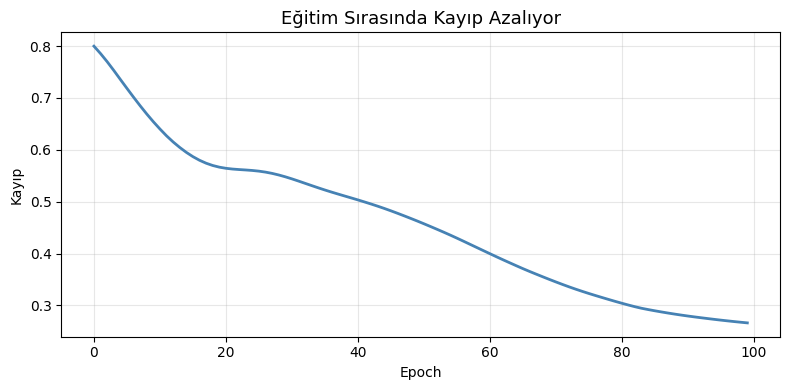

In [9]:
kayip_fn  = nn.BCELoss()                           # ikili çapraz entropi
optimizer = optim.Adam(model.parameters(), lr=0.01)

kayip_gecmisi = []

for epoch in range(1, 101):

    # ① Tahmin yap
    tahmin = model(X_train_t)

    # ② Kaybı hesapla
    kayip = kayip_fn(tahmin, y_train_t)

    # ③ Gradyanları sıfırla ve geri yayılımı çalıştır
    optimizer.zero_grad()  # önceki gradyanları temizle
    kayip.backward()       # her ağırlığın kaybı nasıl etkilediğini hesapla

    # ④ Ağırlıkları güncelle
    optimizer.step()

    kayip_gecmisi.append(kayip.item())

    if epoch % 25 == 0:
        with torch.no_grad():
            test_pred = model(X_test_t)
            dogru = ((test_pred > 0.5).float() == y_test_t).float().mean()
        print(f"Epoch {epoch:3d} | Kayıp: {kayip.item():.4f} | Test Doğruluğu: {dogru*100:.1f}%")

# Kayıp grafiği
plt.figure(figsize=(8, 4))
plt.plot(kayip_gecmisi, color='steelblue', linewidth=2)
plt.title('Eğitim Sırasında Kayıp Azalıyor', fontsize=13)
plt.xlabel('Epoch')
plt.ylabel('Kayıp')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [10]:
# Final test + birkaç örnek tahmin
model.eval()
with torch.no_grad():
    test_pred = model(X_test_t)
    dogruluk  = ((test_pred > 0.5).float() == y_test_t).float().mean()

print(f"Final Test Doğruluğu: {dogruluk*100:.1f}%")
print()
print("Örnek Tahminler:")
print(f"{'Gerçek':>10} {'Tahmin (%)':>12} {'Karar':>10}")
print("-" * 35)
for i in range(8):
    gercek = int(y_test_t[i].item())
    olas   = test_pred[i].item()
    karar  = "✅ Onay" if olas > 0.5 else "❌ Red"
    print(f"{gercek:>10} {olas*100:>11.1f}% {karar:>10}")

Final Test Doğruluğu: 92.0%

Örnek Tahminler:
    Gerçek   Tahmin (%)      Karar
-----------------------------------
         0        11.6%      ❌ Red
         0         8.9%      ❌ Red
         0        31.0%      ❌ Red
         0         4.1%      ❌ Red
         0         1.4%      ❌ Red
         1        58.2%     ✅ Onay
         0         5.2%      ❌ Red
         0         0.2%      ❌ Red


---
## 🎯 Özet — Aklında Kalsın

| Kavram | Ne Anlama Gelir | Günlük Benzetme |
|---|---|---|
| **Nöron** | Sayıları toplayıp karar verir | Oy sayma makinesi |
| **Ağırlık** | Girdinin önemi | Sınav sorusunun puanı |
| **Bias** | Temel eğilim | Kapı eşiği |
| **Aktivasyon** | Doğrusal olmama katar | Açma/kapama düğmesi |
| **Kayıp** | Hata miktarı | Sınav notu |
| **Gradient Descent** | Hatayı azaltmak için adım at | Dağdan inerken yol bul |
| **Epoch** | Tüm veriyi bir kez gör | Kitabı baştan okuma |

---

**Sonraki adım:** CNN (Görüntü), RNN (Metin), Transfer Learning 🚀